In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Using the gradient in the loop.

In [2]:
def get_reach_boxes(file_path: str, variables: list[str], search: str) -> list[dict[str, list[float]]]:
    variable_bounds = []
    with open(file_path, 'r') as file:
        lines = file.readlines()
    i = 0
    while i < len(lines):
        line = lines[i].strip()
        if line.startswith("Dealing with the jump from " + search):
            bounds_dict = {}
            i += 1
            while i < len(lines) and not lines[i].strip().startswith("Done."):
                line = lines[i].strip()
                for var in variables:
                    if f"{var} bounds after reset:" in line:
                        start = line.find('[')
                        end = line.find(']')
                        if start != -1 and end != -1:
                            bounds_str = line[start+1:end]
                            lower, upper = map(float, bounds_str.split(','))
                            bounds_dict[var] = [lower, upper]
                i += 1
            if bounds_dict:
                variable_bounds.append(bounds_dict)
        else:
            i += 1
    return variable_bounds

In [3]:
import matplotlib.patches as patches
def create_reach_plots(reach_boxes=None, xlims=[-1,1], ylims=[-1,1], figsize=(9,6)):
    fig, ax1 = plt.subplots(layout='constrained', figsize=figsize)
    x_min, x_max = xlims
    ax1.set_xlim(x_min, x_max)
    ax1.set_ylim(ylims)


    if reach_boxes is not None:
        for setting in reach_boxes:
            for i, box in enumerate(get_reach_boxes(setting['filename'], setting['vars'], setting['search'])):
                x1, x2 = box[setting['vars'][0]]
                y1, y2 = box[setting['vars'][1]]
                # Skip if any values are nan or very large
                if np.isnan(x1) or np.isnan(x2) or np.isnan(y1) or np.isnan(y2):
                    continue
                if np.abs(x1) > 1e6 or np.abs(x2) > 1e6 or np.abs(y1) > 1e6 or np.abs(y2) > 1e6:
                    continue

                rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                        linewidth=2, edgecolor=setting['color'],
                                        facecolor='none', zorder=5, label=setting['label'] if i == 0 else "")
                ax1.add_patch(rect)
                
        ax1.legend()
    return fig

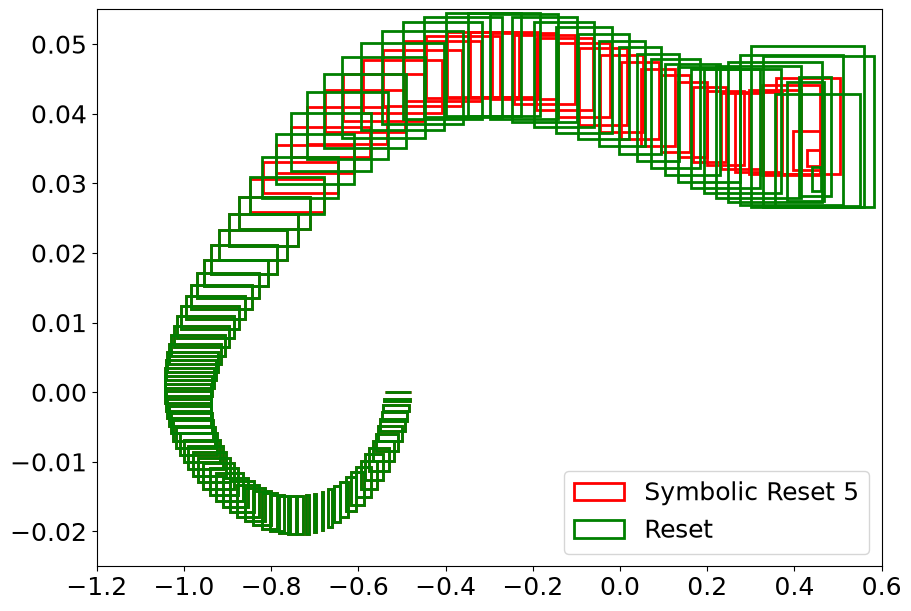

In [4]:
plt.rcParams.update({'font.size': 18})
f = create_reach_plots(reach_boxes=[{
                       "filename": "../outputs/out_sym_5.txt",
                       "color": "red",
                       "vars" : ["x1","x2"],
                       "label": "Symbolic Reset 5",
                       "search" : "DNN to _symbolic"
                   },
                   {
                       "filename": "../outputs/out_reset.xml",
                       "color": "green",
                       "vars" : ["x1","x2"],
                       "label": "Reset",
                       "search" : "DNN to _reset"
                   }
                   ], xlims=[-1.2,0.6], ylims=[-0.025, 0.055])
